# importing libraries

In [24]:
pip install keras

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import keras

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import preprocessing
import keras
import tensorflow as tf

# reading the data

In [3]:
ipl=pd.read_csv(r"C:\Users\G Supriya\OneDrive\Desktop\Intership_python\datasets\ipl_data.csv")

# Analysing the data

In [45]:
ipl.head()

,mid,date,venue,bat_team,bowl_team,batsman,bowler,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
0,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,1,0,0.1,1,0,0,0,222
1,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,1,0,0.2,1,0,0,0,222
2,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.2,2,0,0,0,222
3,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.3,2,0,0,0,222
4,1,2008-04-18,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,2,0,0.4,2,0,0,0,222


In [5]:
ipl["venue"].nunique()

35

(138,)

In [6]:
ipl.shape

(76014, 15)

In [7]:
ipl.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 76014 entries, 0 to 76013
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   mid             76014 non-null  int64  
 1   date            76014 non-null  object 
 2   venue           76014 non-null  object 
 3   bat_team        76014 non-null  object 
 4   bowl_team       76014 non-null  object 
 5   batsman         76014 non-null  object 
 6   bowler          76014 non-null  object 
 7   runs            76014 non-null  int64  
 8   wickets         76014 non-null  int64  
 9   overs           76014 non-null  float64
 10  runs_last_5     76014 non-null  int64  
 11  wickets_last_5  76014 non-null  int64  
 12  striker         76014 non-null  int64  
 13  non-striker     76014 non-null  int64  
 14  total           76014 non-null  int64  
dtypes: float64(1), int64(8), object(6)
memory usage: 8.7+ MB


In [8]:
ipl.describe()

,mid,runs,wickets,overs,runs_last_5,wickets_last_5,striker,non-striker,total
count,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000,76014.000000
mean,308.627740,74.889349,2.415844,9.783068,33.216434,1.120307,24.962283,8.869287,160.901452
std,178.156878,48.823327,2.015207,5.772587,14.914174,1.053343,20.079752,10.795742,29.246231
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,67.000000
25%,154.000000,34.000000,1.000000,4.600000,24.000000,0.000000,10.000000,1.000000,142.000000
50%,308.000000,70.000000,2.000000,9.600000,34.000000,1.000000,20.000000,5.000000,162.000000
75%,463.000000,111.000000,4.000000,14.600000,43.000000,2.000000,35.000000,13.000000,181.000000
max,617.000000,263.000000,10.000000,19.600000,113.000000,7.000000,175.000000,109.000000,263.000000


# Dropping unneccessary columns

In [9]:
df=ipl.drop(["date","runs","wickets","overs","runs_last_5","wickets_last_5","mid","striker","non-striker"],axis=1)

In [10]:
df.head()

,venue,bat_team,bowl_team,batsman,bowler,total
0,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar,222
1,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,222
2,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,222
3,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,222
4,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar,222


In [11]:
x=df.drop(["total"],axis=1)
y=df["total"]

In [12]:
x

,venue,bat_team,bowl_team,batsman,bowler
0,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,SC Ganguly,P Kumar
1,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar
2,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar
3,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar
4,M Chinnaswamy Stadium,Kolkata Knight Riders,Royal Challengers Bangalore,BB McCullum,P Kumar
...,...,...,...,...,...
76009,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian
76010,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian
76011,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,KH Pandya,DT Christian
76012,"Rajiv Gandhi International Stadium, Uppal",Mumbai Indians,Rising Pune Supergiant,MG Johnson,DT Christian


In [13]:
y

0        222
1        222
2        222
3        222
4        222
        ... 
76009    129
76010    129
76011    129
76012    129
76013    129
Name: total, Length: 76014, dtype: int64

# Encoding the categorical values to numerical velues using LabelEncoder

In [14]:
from sklearn.preprocessing import LabelEncoder
venue_encoder=LabelEncoder()
batting_team_encoder=LabelEncoder()
bowling_team_encoder=LabelEncoder()
striker_encoder=LabelEncoder()
bowler_encoder=LabelEncoder()

x["venue"]=venue_encoder.fit_transform(x["venue"])
x["bat_team"]=batting_team_encoder.fit_transform(x["bat_team"])
x["bowl_team"]=bowling_team_encoder.fit_transform(x["bowl_team"])
x["batsman"]=striker_encoder.fit_transform(x["batsman"])
x["bowler"]=bowler_encoder.fit_transform(x["bowler"])

In [15]:
x

,venue,bat_team,bowl_team,batsman,bowler
0,14,6,12,328,201
1,14,6,12,61,201
2,14,6,12,61,201
3,14,6,12,61,201
4,14,6,12,61,201
...,...,...,...,...,...
76009,23,7,10,172,96
76010,23,7,10,172,96
76011,23,7,10,172,96
76012,23,7,10,215,96


# splitting the dataset train dataset and test data set

In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.3,random_state=42)

# Scaling the numerical values for better model prediction

In [17]:
from sklearn.preprocessing import MinMaxScaler
scaler=MinMaxScaler()
X_train_scaled=scaler.fit_transform(X_train)
X_test_scaled=scaler.fit_transform(X_test)

In [18]:
X_test

,venue,bat_team,bowl_team,batsman,bowler
12590,18,2,12,122,128
74893,9,3,2,171,72
56763,34,7,0,133,228
19428,1,7,2,350,210
30216,5,0,1,284,40
...,...,...,...,...,...
52464,14,12,2,19,191
23921,8,2,4,93,207
24202,26,5,9,284,280
61097,22,4,0,126,7


In [19]:
X_test_scaled

array([[0.52941176, 0.15384615, 0.92307692, 0.29756098, 0.3902439 ],
       [0.26470588, 0.23076923, 0.15384615, 0.41707317, 0.2195122 ],
       [1.        , 0.53846154, 0.        , 0.32439024, 0.69512195],
       ...,
       [0.76470588, 0.38461538, 0.69230769, 0.69268293, 0.85365854],
       [0.64705882, 0.30769231, 0.        , 0.30731707, 0.02134146],
       [0.73529412, 0.84615385, 0.23076923, 0.2902439 , 0.25      ]])

In [20]:
X_train

,venue,bat_team,bowl_team,batsman,bowler
31043,15,12,0,78,121
1720,22,2,4,393,48
62369,14,12,13,384,175
74763,21,4,6,398,157
10506,2,7,2,266,218
...,...,...,...,...,...
37194,34,6,7,221,272
6265,26,7,9,347,292
54886,1,7,0,213,183
860,15,0,7,258,275


In [21]:
X_train_scaled

array([[0.44117647, 0.92307692, 0.        , 0.1902439 , 0.36890244],
       [0.64705882, 0.15384615, 0.30769231, 0.95853659, 0.14634146],
       [0.41176471, 0.92307692, 1.        , 0.93658537, 0.53353659],
       ...,
       [0.02941176, 0.53846154, 0.        , 0.5195122 , 0.55792683],
       [0.44117647, 0.        , 0.53846154, 0.62926829, 0.83841463],
       [0.41176471, 0.92307692, 0.        , 0.93658537, 0.5152439 ]])

#  creating the Model

In [22]:
X_train_scaled.shape[1]

5

In [25]:
model=keras.Sequential([
    keras.layers.Input(shape=(X_train_scaled.shape[1],)),
    keras.layers.Dense(512,activation='relu'),
    keras.layers.Dense(216,activation='relu'),
    keras.layers.Dense(1,activation='linear')
])
huber_loss=tf.keras.losses.Huber(delta=1.0)
model.compile(optimizer='adam',loss=huber_loss)

# model training

In [29]:
model.fit(X_train_scaled,y_train,epochs=40,batch_size=64,validation_data=(X_test_scaled,y_test))

Epoch 1/40
832/832 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 21.3982 - val_loss: 21.1153
Epoch 2/40
832/832 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 21.1826 - val_loss: 21.3455
Epoch 3/40
832/832 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 21.3686 - val_loss: 20.9687
Epoch 4/40
832/832 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 21.0273 - val_loss: 20.9097
Epoch 5/40
832/832 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 21.3215 - val_loss: 20.9463
Epoch 6/40
832/832 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 21.1847 - val_loss: 21.0336
Epoch 7/40
832/832 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 20.8899 - val_loss: 21.0521
Epoch 8/40
832/832 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 20.8626 - val_loss: 20.6628
Epoch 9/40
832/832 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 20.9448 - val_loss: 20.8425
Epoch 10/40
832/832 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 20.8370 - val_loss: 20.7270
Epoch 11/40
832/832 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 20.7315 - val_loss: 20.5602
Epoch 12/40
832/832 ━━━━━━━━━

Text(0.5, 1.0, 'Epoch vs Loss & Validation Loss')

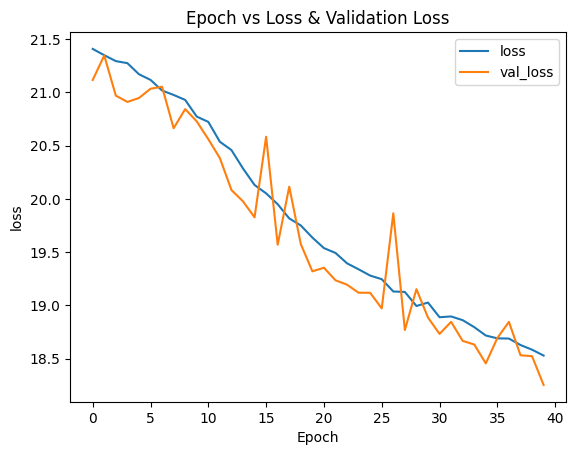

In [41]:
model_losses=pd.DataFrame(model.history.history)
model_losses.plot()
plt.xlabel("Epoch")
plt.ylabel("loss")
plt.title("Epoch vs Loss & Validation Loss")

# Model Evaluation

In [53]:
predictions=model.predict(X_test_scaled)
from sklearn.metrics import mean_absolute_error,mean_squared_error
print("Mean Absolute error :",mean_absolute_error(y_test,predictions))
np.sqrt(mean_squared_error(y_test,predictions))



713/713 ━━━━━━━━━━━━━━━━━━━━ 0s 631us/step
Mean Absolute error : 18.743369542953868


25.99139860703713

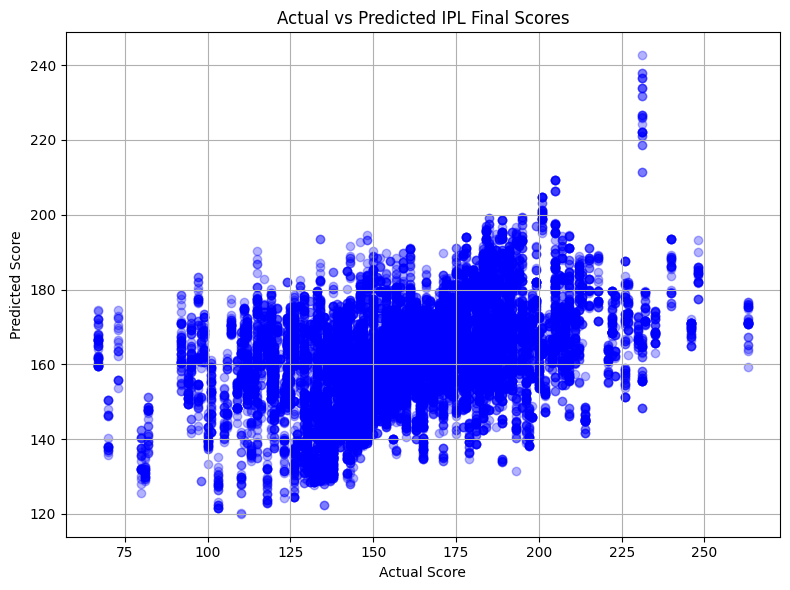

In [52]:
plt.figure(figsize=(8, 6))
plt.scatter(y_test, predictions, alpha=0.3, color='blue')
plt.xlabel("Actual Score")
plt.ylabel("Predicted Score")
plt.title("Actual vs Predicted IPL Final Scores")
plt.grid(True)
plt.tight_layout()
plt.show()

In [38]:
import ipywidgets as widgets
from IPython.display import display, clear_output

import warnings
warnings.filterwarnings("ignore")

venue = widgets.Dropdown(options=df['venue'].unique().tolist(),description='Select Venue:')
batting_team = widgets.Dropdown(options =df['bat_team'].unique().tolist(),  description='Select Batting Team:')
bowling_team = widgets.Dropdown(options=df['bowl_team'].unique().tolist(),  description='Select Bowling Team:')
striker = widgets.Dropdown(options=df['batsman'].unique().tolist(), description='Select Striker:')
bowler = widgets.Dropdown(options=df['bowler'].unique().tolist(), description='Select Bowler:')

predict_button = widgets.Button(description="Predict Score")

def predict_score(b):
    with output:
        clear_output()  # Clear the previous output
        

        # Decode the encoded values back to their original values
        decoded_venue = venue_encoder.transform([venue.value])
        decoded_batting_team = batting_team_encoder.transform([batting_team.value])
        decoded_bowling_team = bowling_team_encoder.transform([bowling_team.value])
        decoded_striker = striker_encoder.transform([striker.value])
        decoded_bowler = bowler_encoder.transform([bowler.value])


        input = np.array([decoded_venue,  decoded_batting_team, decoded_bowling_team,decoded_striker, decoded_bowler])
        input = input.reshape(1,5)
        input = scaler.transform(input)
        #print(input)
        predicted_score = model.predict(input)
        predicted_score = int(predicted_score[0,0])

        print(f"PREDICTED SCORE IS: {predicted_score}")


In [40]:
predict_button.on_click(predict_score)
output = widgets.Output()
display(venue, batting_team, bowling_team, striker, bowler, predict_button, output)


Dropdown(description='Select Venue:', index=3, options=('M Chinnaswamy Stadium', 'Punjab Cricket Association S…

Dropdown(description='Select Batting Team:', index=3, options=('Kolkata Knight Riders', 'Chennai Super Kings',…

Dropdown(description='Select Bowling Team:', index=6, options=('Royal Challengers Bangalore', 'Kings XI Punjab…

Dropdown(description='Select Striker:', index=34, options=('SC Ganguly', 'BB McCullum', 'RT Ponting', 'DJ Huss…

Dropdown(description='Select Bowler:', index=38, options=('P Kumar', 'Z Khan', 'AA Noffke', 'JH Kallis', 'SB J…

Button(description='Predict Score', style=ButtonStyle())

Output()